In [1]:
import warnings
warnings.simplefilter("ignore", UserWarning)

import scanpy as sc
import numpy as np
import pandas as pd
import os
# import rapids_singlecell as rsc
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib as mpl
# enables correct plotting of text
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 

In [2]:
import session_info
session_info.show()

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  mod_version = _find_version(mod.__version__)


In [3]:
sc.settings.set_figure_params(dpi=120)

In [4]:
figdir = '/rfs/project/rfs-iCNyzSAaucw/kk837/notebooks/Foetal/Revision_Oct2025/fetal_ms_figures'

# Read in

In [5]:
objects_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium'
path_adata = f'{objects_dir}/TACCO/tacco-splitted_filtered_raw.h5ad'
adata = sc.read_h5ad(path_adata)
adata

AnnData object with n_obs × n_vars = 333364 × 5001
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'tissue_block_id', 'celltypist_coarse', 'conf_score_coarse', 'celltypist_coarse_fin', 'celltypist_coarse2midmod', 'conf_score_coarse2midmod', 'celltypist_mid_fin', 'celltypist_midmod2fine', 'conf_score_midmod2fine', 'pca_harmony_leiden_0.2', 'pca_harmony_leiden_0.3', 'pca_harmony_leiden_0.4', 'pca_harmony_leiden_0.5', 'pca_harmony_leiden_0.8', 'pca_harmony_leiden_1.0', 'pca_harmony_leiden_1.5', 'pca_harmony_leiden_2.0', 'pca_harmony_leiden_

# Integration

In [6]:
adata_lognorm = adata.copy()
# filter genes
sc.pp.filter_genes(adata_lognorm, min_cells=3)
# log-normalise the count
sc.pp.normalize_total(adata_lognorm,target_sum=1e4)
sc.pp.log1p(adata_lognorm)
adata_lognorm.X.data[:5]

# PCA
# Create simple reduced dimensional space using PCA
sc.tl.pca(adata_lognorm)

# Harmony
import scanpy.external as sce
sce.pp.harmony_integrate(adata_lognorm, 'tissue_block_id', basis='X_pca', adjusted_basis='X_pca_harmony')

2026-04-14 13:19:06,732 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-04-14 13:19:25,481 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-04-14 13:19:26,610 - harmonypy - INFO - Iteration 1 of 10
2026-04-14 13:20:52,219 - harmonypy - INFO - Iteration 2 of 10
2026-04-14 13:22:17,749 - harmonypy - INFO - Iteration 3 of 10
2026-04-14 13:23:43,431 - harmonypy - INFO - Iteration 4 of 10
2026-04-14 13:25:09,853 - harmonypy - INFO - Iteration 5 of 10
2026-04-14 13:26:32,710 - harmonypy - INFO - Iteration 6 of 10
2026-04-14 13:26:58,754 - harmonypy - INFO - Iteration 7 of 10
2026-04-14 13:27:24,694 - harmonypy - INFO - Iteration 8 of 10
2026-04-14 13:27:50,953 - harmonypy - INFO - Iteration 9 of 10
2026-04-14 13:28:17,410 - harmonypy - INFO - Iteration 10 of 10
2026-04-14 13:28:43,808 - harmonypy - INFO - Stopped before convergence


In [7]:
# add to original adata
adata.uns['pca'] = adata_lognorm.uns['pca'].copy()
adata.obsm['X_pca'] = adata_lognorm.obsm['X_pca'].copy()
adata.obsm['X_pca_harmony'] = adata_lognorm.obsm['X_pca_harmony'].copy()
adata.varm['PCs'] = adata_lognorm.varm['PCs'].copy()
adata

AnnData object with n_obs × n_vars = 333364 × 5001
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'tissue_block_id', 'celltypist_coarse', 'conf_score_coarse', 'celltypist_coarse_fin', 'celltypist_coarse2midmod', 'conf_score_coarse2midmod', 'celltypist_mid_fin', 'celltypist_midmod2fine', 'conf_score_midmod2fine', 'pca_harmony_leiden_0.2', 'pca_harmony_leiden_0.3', 'pca_harmony_leiden_0.4', 'pca_harmony_leiden_0.5', 'pca_harmony_leiden_0.8', 'pca_harmony_leiden_1.0', 'pca_harmony_leiden_1.5', 'pca_harmony_leiden_2.0', 'pca_harmony_leiden_

# kNN graph and UMAP

In [8]:
key_added = 'pca_harmony'
print("making kNN graph...")
sc.pp.neighbors(adata,use_rep=f"X_{key_added}",key_added=key_added)
print("computing UMAP coordinates...")
sc.tl.umap(adata, min_dist=0.2, neighbors_key=key_added)
adata.obsm[f"X_umap_{key_added}"]=adata.obsm["X_umap"] # rename the generic X_umap coordinates
del adata.obsm["X_umap"]

making kNN graph...


/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


computing UMAP coordinates...


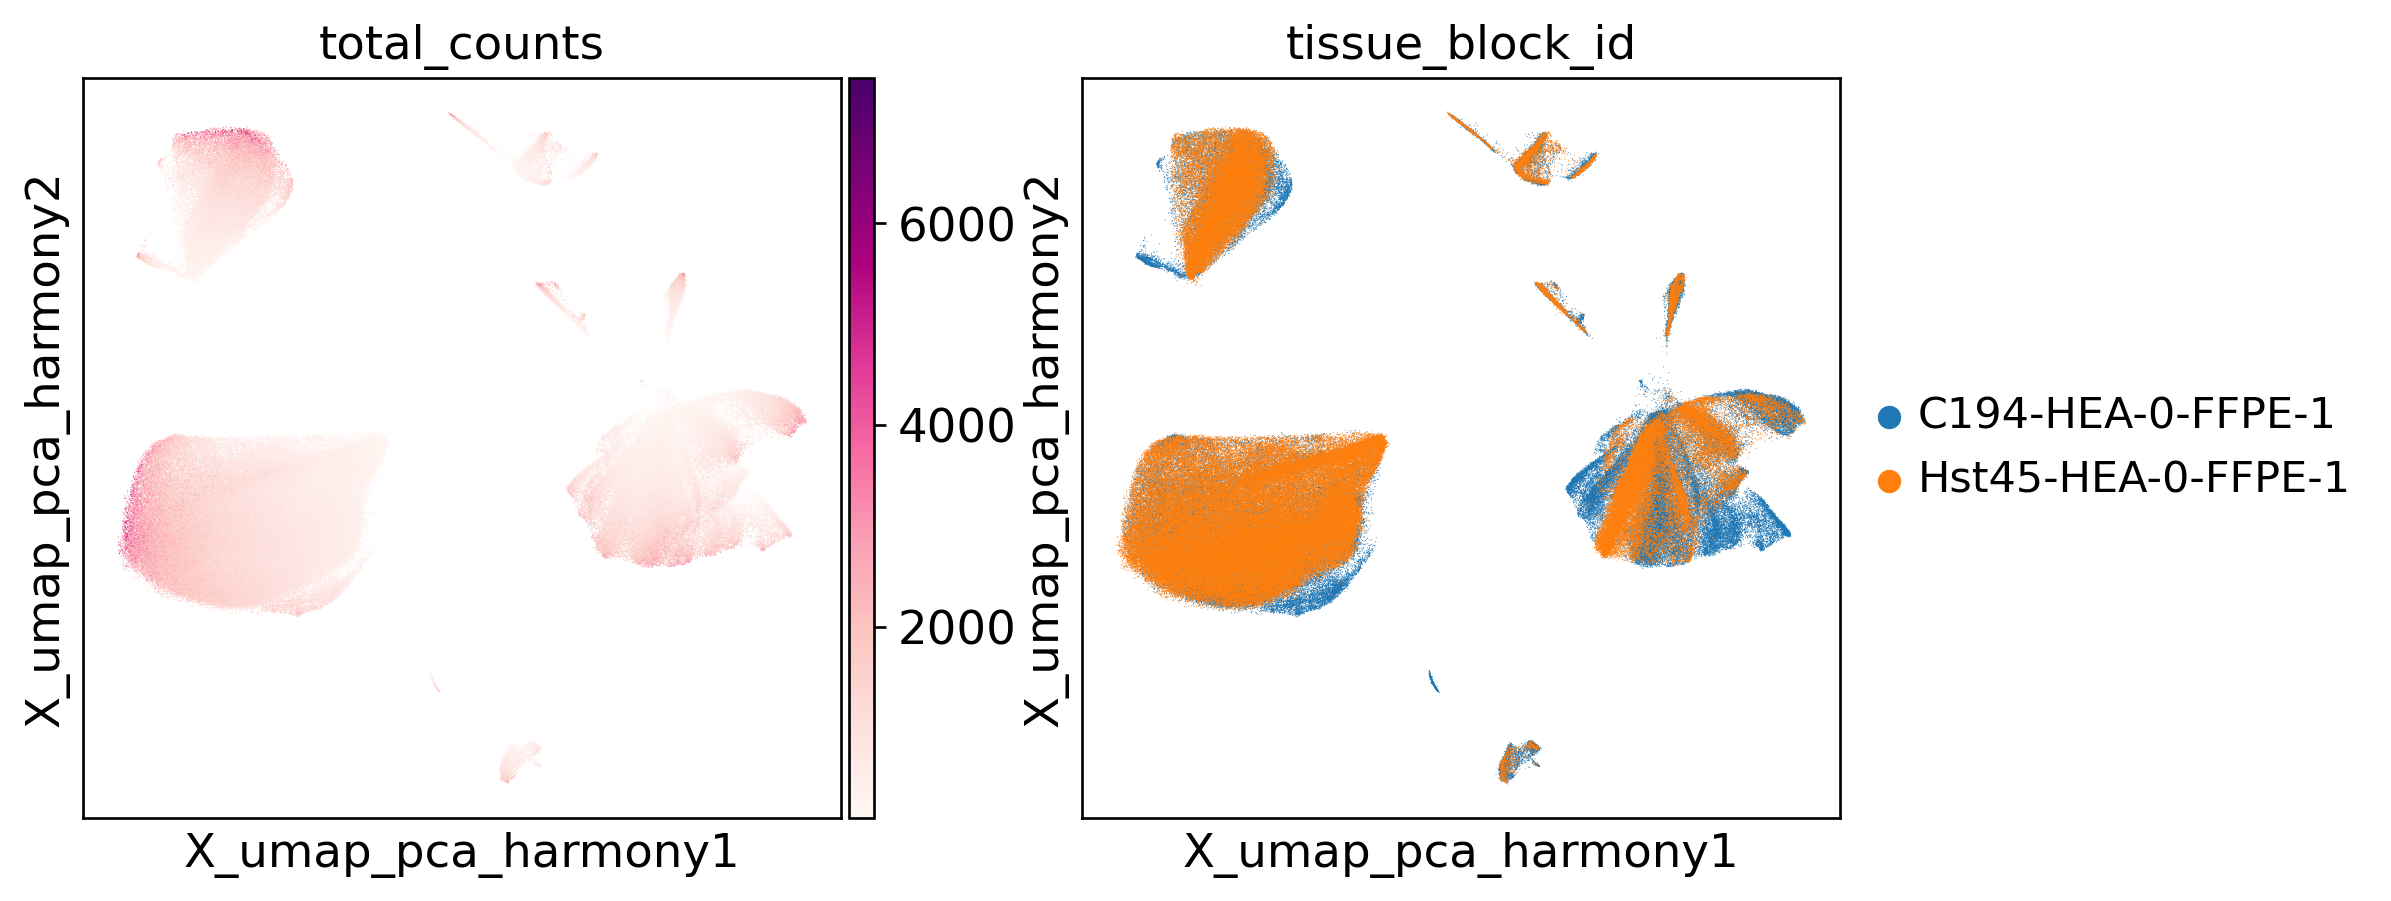

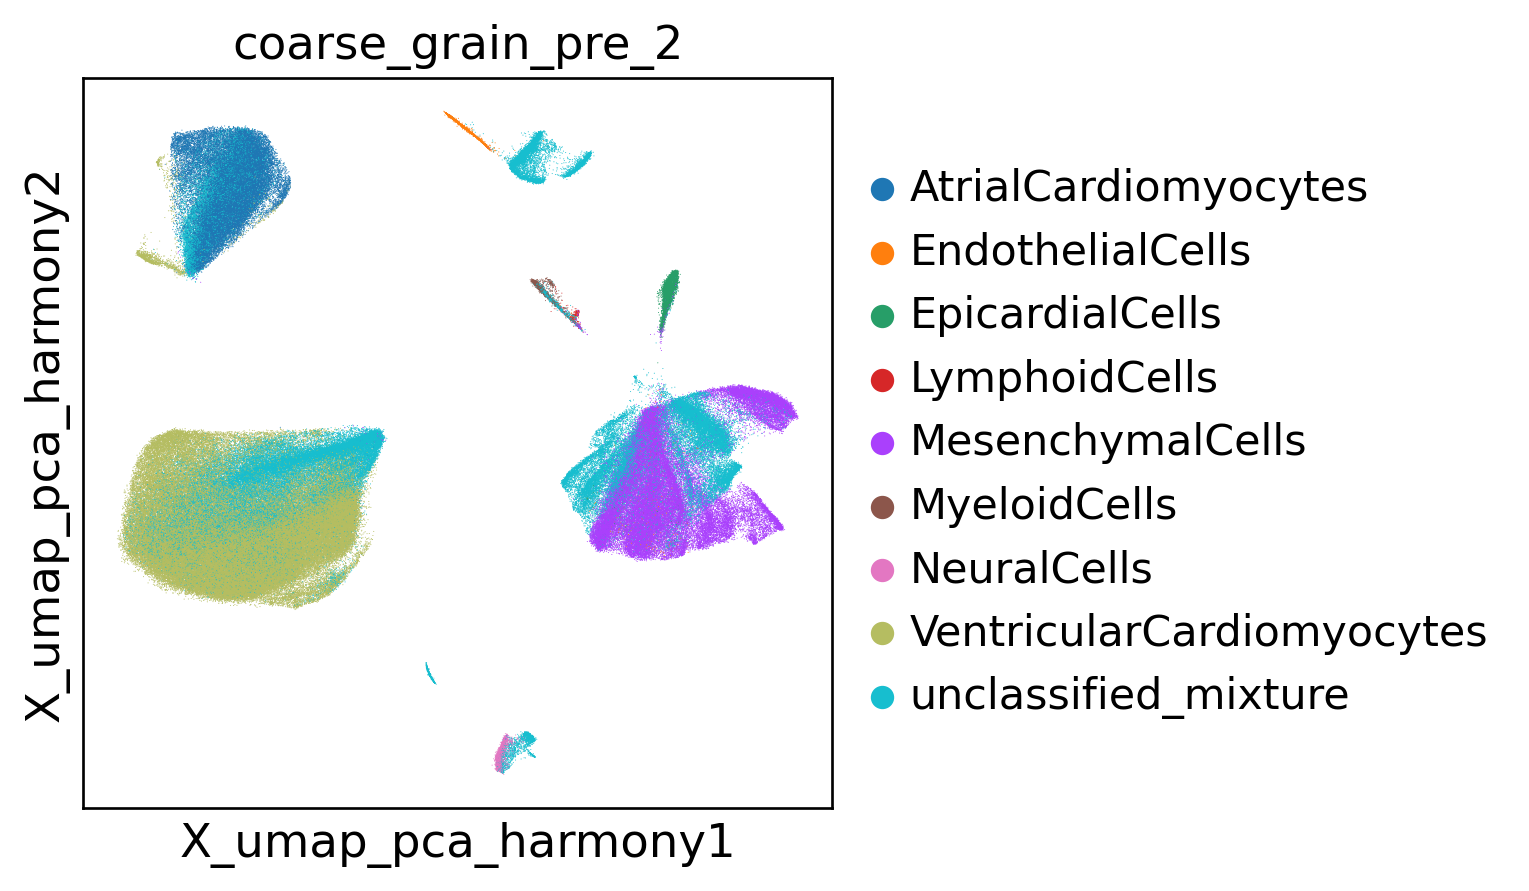

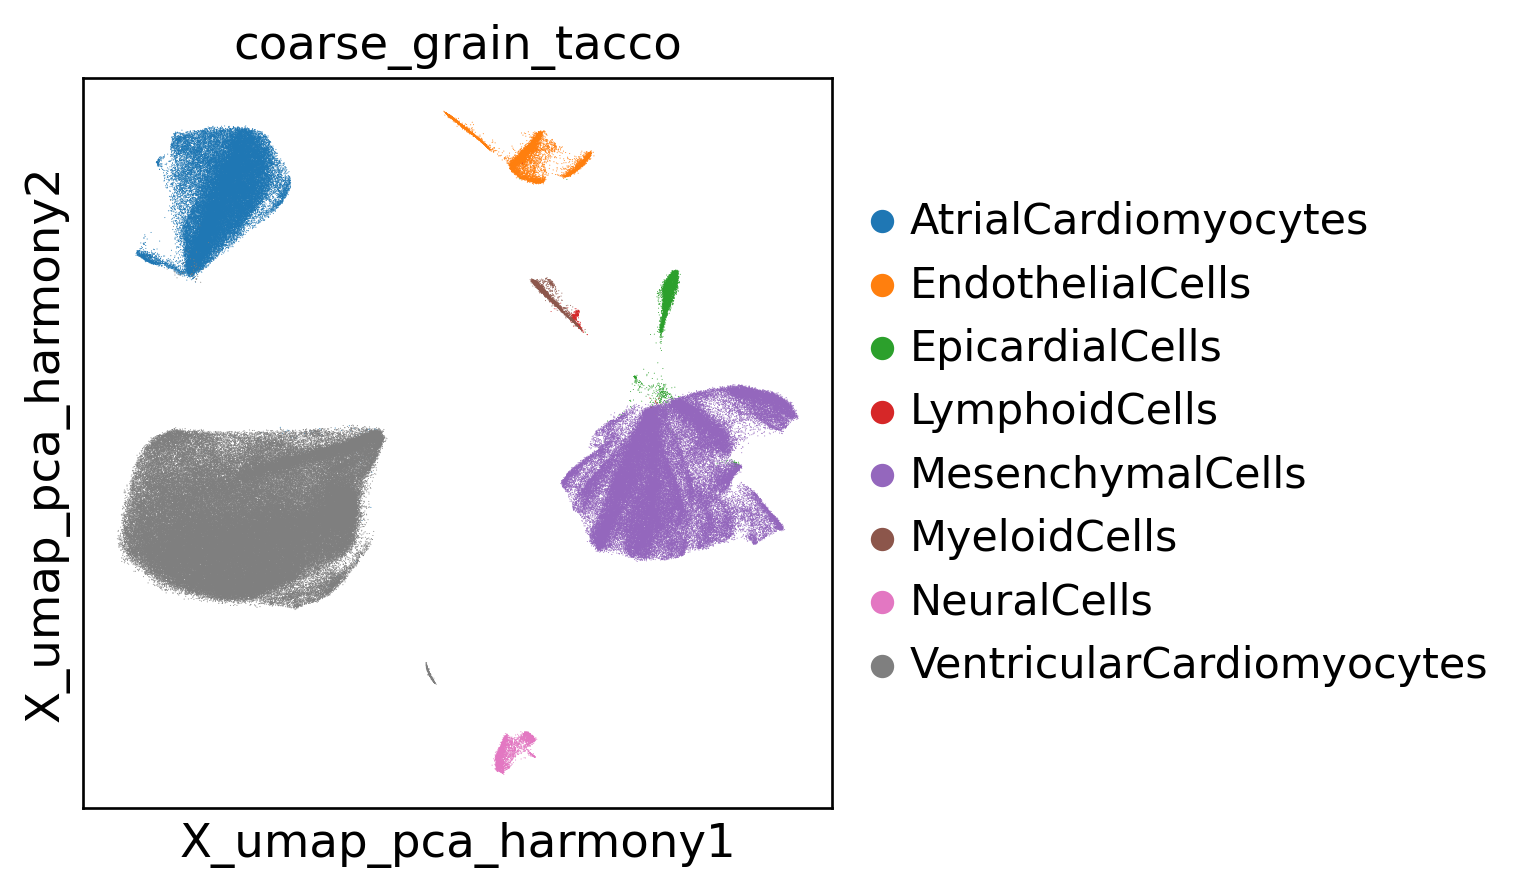

In [9]:
sc.pl.embedding(adata, basis=f"X_umap_{key_added}",
                color=['total_counts','tissue_block_id'], wspace=0.2, cmap='RdPu')
sc.pl.embedding(adata, basis=f"X_umap_{key_added}",
                color=['coarse_grain_pre_2'], wspace=0.2, cmap='RdPu')
sc.pl.embedding(adata, basis=f"X_umap_{key_added}",
                color=['coarse_grain_tacco'], wspace=0.2, cmap='RdPu')

# Save

In [13]:
set(adata.obs['coarse_grain_tacco'])

{'AtrialCardiomyocytes',
 'EndothelialCells',
 'EpicardialCells',
 'LymphoidCells',
 'MesenchymalCells',
 'MyeloidCells',
 'NeuralCells',
 'VentricularCardiomyocytes'}

In [26]:
# set category: 'coarse_grain_tacco'
celltype_order = [
    'AtrialCardiomyocytes',
    'VentricularCardiomyocytes',
    'MesenchymalCells',
    'EndothelialCells',
    'EpicardialCells',
    'NeuralCells',
    'MyeloidCells',
    'LymphoidCells',
]

adata.obs['coarse_grain_tacco'] = adata.obs['coarse_grain_tacco'].astype('str').astype('category')
adata.obs['coarse_grain_tacco'] = adata.obs['coarse_grain_tacco'].cat.reorder_categories(
    celltype_order
)
print(adata.obs['coarse_grain_tacco'].cat.categories)

# set category: 'coarse_grain_pre_2'
adata.obs['coarse_grain_pre_2'] = adata.obs['coarse_grain_pre_2'].astype('str').astype('category')
adata.obs['coarse_grain_pre_2'] = adata.obs['coarse_grain_pre_2'].cat.reorder_categories(
    celltype_order+['unclassified_mixture']
)
print(adata.obs['coarse_grain_pre_2'].cat.categories)

Index(['AtrialCardiomyocytes', 'VentricularCardiomyocytes', 'MesenchymalCells',
       'EndothelialCells', 'EpicardialCells', 'NeuralCells', 'MyeloidCells',
       'LymphoidCells'],
      dtype='object')
Index(['AtrialCardiomyocytes', 'VentricularCardiomyocytes', 'MesenchymalCells',
       'EndothelialCells', 'EpicardialCells', 'NeuralCells', 'MyeloidCells',
       'LymphoidCells', 'unclassified_mixture'],
      dtype='object')


In [27]:
adata.write(path_adata)
adata

AnnData object with n_obs × n_vars = 333364 × 5001
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'tissue_block_id', 'celltypist_coarse', 'conf_score_coarse', 'celltypist_coarse_fin', 'celltypist_coarse2midmod', 'conf_score_coarse2midmod', 'celltypist_mid_fin', 'celltypist_midmod2fine', 'conf_score_midmod2fine', 'pca_harmony_leiden_0.2', 'pca_harmony_leiden_0.3', 'pca_harmony_leiden_0.4', 'pca_harmony_leiden_0.5', 'pca_harmony_leiden_0.8', 'pca_harmony_leiden_1.0', 'pca_harmony_leiden_1.5', 'pca_harmony_leiden_2.0', 'pca_harmony_leiden_

# Plots for manuscript

In [12]:
adata_pre_tacco = sc.read_h5ad(f'{objects_dir}/C194-HEA-0-FFPE-1_Hst45-HEA-0-FFPE-1_concat_5K_filtered_celltype-sel_raw.h5ad')
adata_pre_tacco

AnnData object with n_obs × n_vars = 341592 × 5001
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'tissue_block_id', 'celltypist_coarse', 'conf_score_coarse', 'celltypist_coarse_fin', 'celltypist_coarse2midmod', 'conf_score_coarse2midmod', 'celltypist_mid_fin', 'celltypist_midmod2fine', 'conf_score_midmod2fine', 'pca_harmony_leiden_0.2', 'pca_harmony_leiden_0.3', 'pca_harmony_leiden_0.4', 'pca_harmony_leiden_0.5', 'pca_harmony_leiden_0.8', 'pca_harmony_leiden_1.0', 'pca_harmony_leiden_1.5', 'pca_harmony_leiden_2.0', 'pca_harmony_leiden_

In [28]:
# set category
adata_pre_tacco.obs['coarse_grain_pre_2'] = adata_pre_tacco.obs['coarse_grain_pre_2'].astype('str')
adata_pre_tacco.obs['coarse_grain_pre_2'] = adata_pre_tacco.obs['coarse_grain_pre_2'].astype('category')
adata_pre_tacco.obs['coarse_grain_pre_2'] = adata_pre_tacco.obs['coarse_grain_pre_2'].cat.reorder_categories(
    celltype_order+['unclassified_mixture']
)
adata_pre_tacco.obs['coarse_grain_pre_2'].cat.categories

Index(['AtrialCardiomyocytes', 'VentricularCardiomyocytes', 'MesenchymalCells',
       'EndothelialCells', 'EpicardialCells', 'NeuralCells', 'MyeloidCells',
       'LymphoidCells', 'unclassified_mixture'],
      dtype='object')

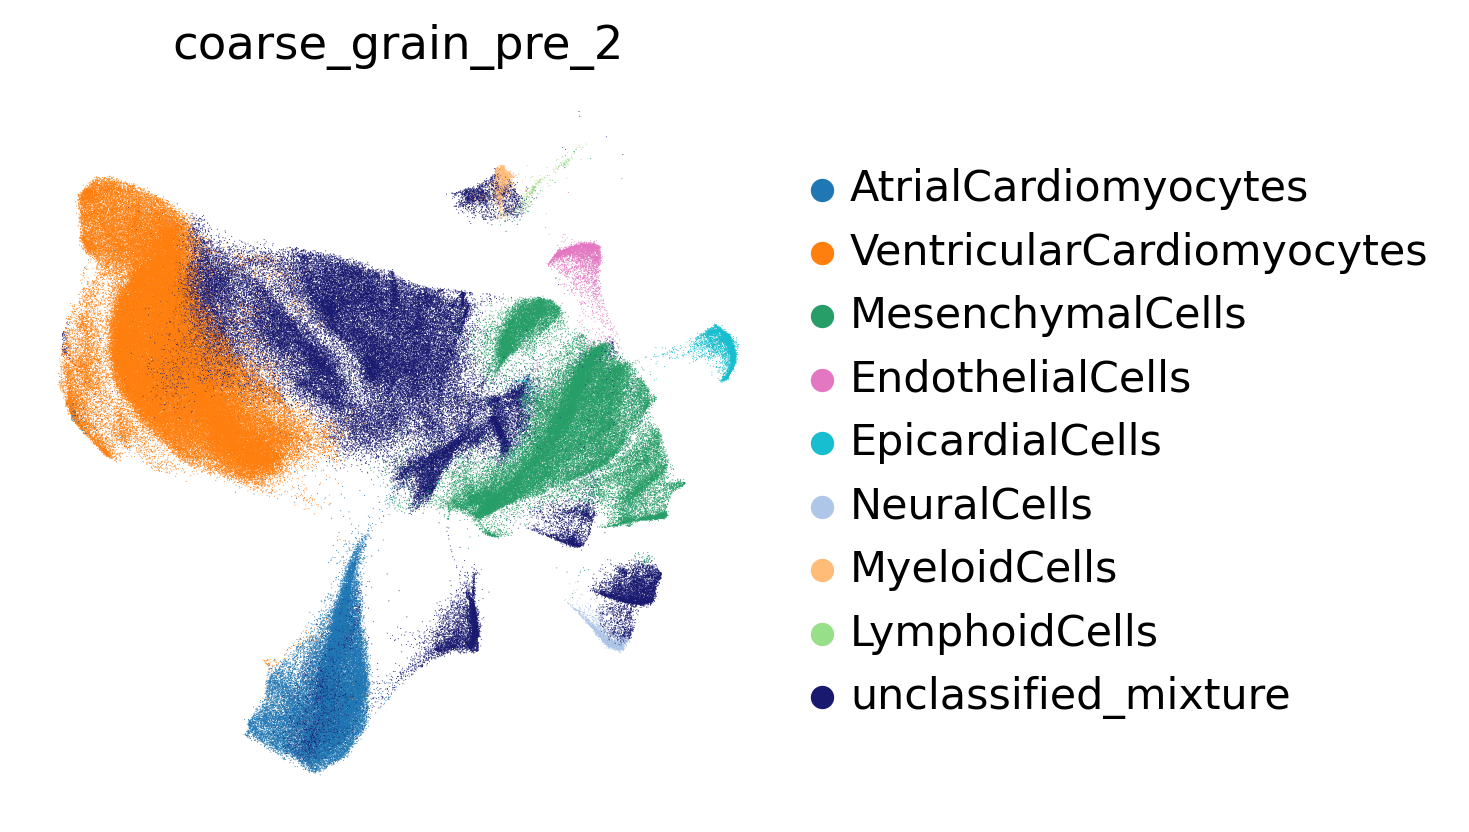

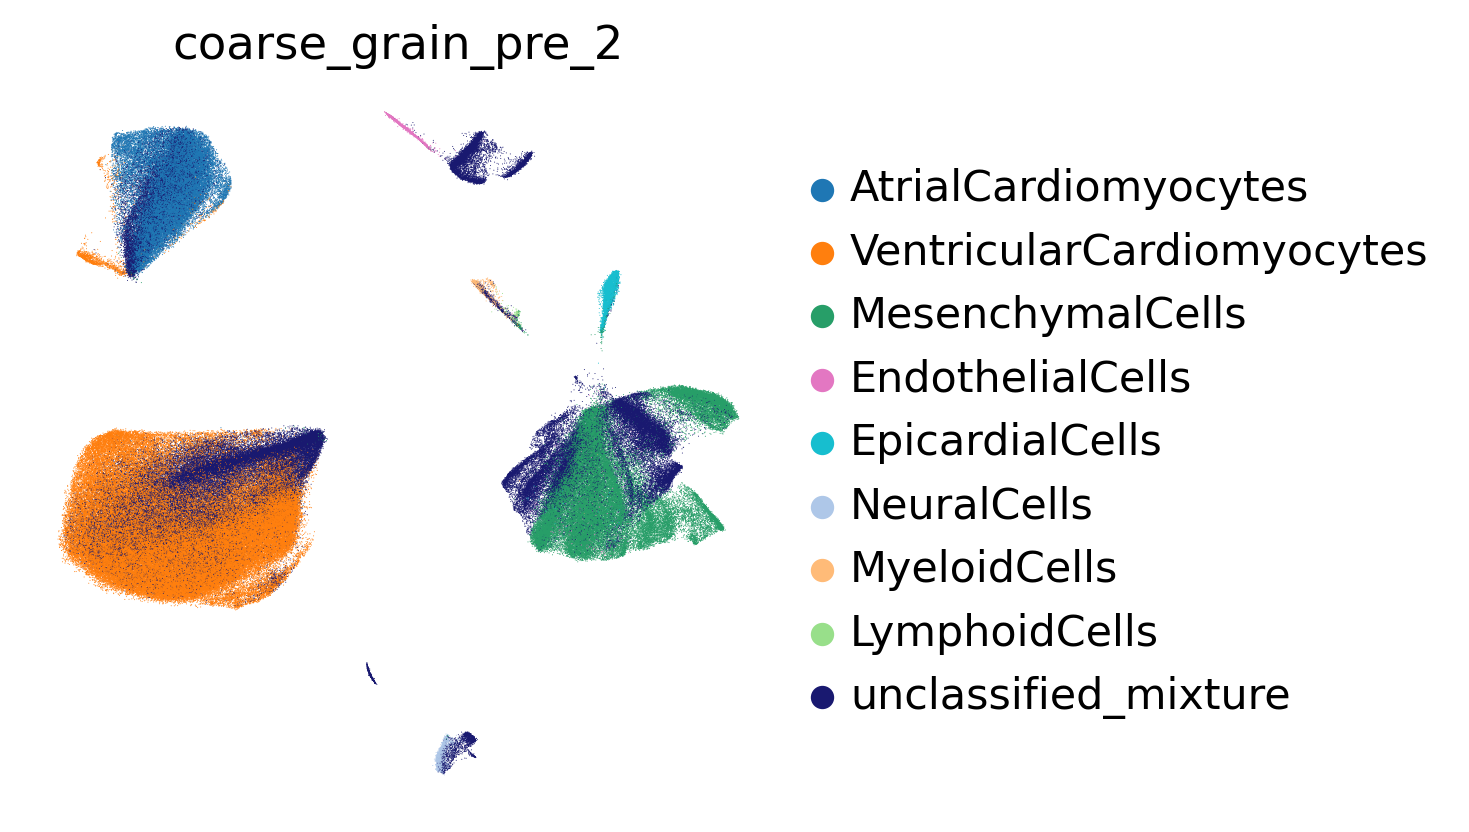

In [29]:
cats = list(adata_pre_tacco.obs['coarse_grain_pre_2'].cat.categories)
colors = list(adata_pre_tacco.uns['coarse_grain_pre_2_colors'])
idx = cats.index("unclassified_mixture")
colors[idx] = "midnightblue"

adata_pre_tacco.uns['coarse_grain_pre_2_colors'] = colors
sc.pl.embedding(adata_pre_tacco, basis=f"X_umap_{key_added}",
               color='coarse_grain_pre_2',
                frameon=False, show=False)
plt.savefig(f'{figdir}/Xenium5K_pre-TACCO_UMAP_coarse_grain_pre_2.pdf', bbox_inches="tight",dpi=300)

adata.uns['coarse_grain_pre_2_colors'] = colors
sc.pl.embedding(adata, basis=f"X_umap_{key_added}",
               color='coarse_grain_pre_2',
                frameon=False,show=False)
plt.savefig(f'{figdir}/Xenium5K_post-TACCO_UMAP_coarse_grain_pre_2.pdf', bbox_inches="tight",dpi=300)

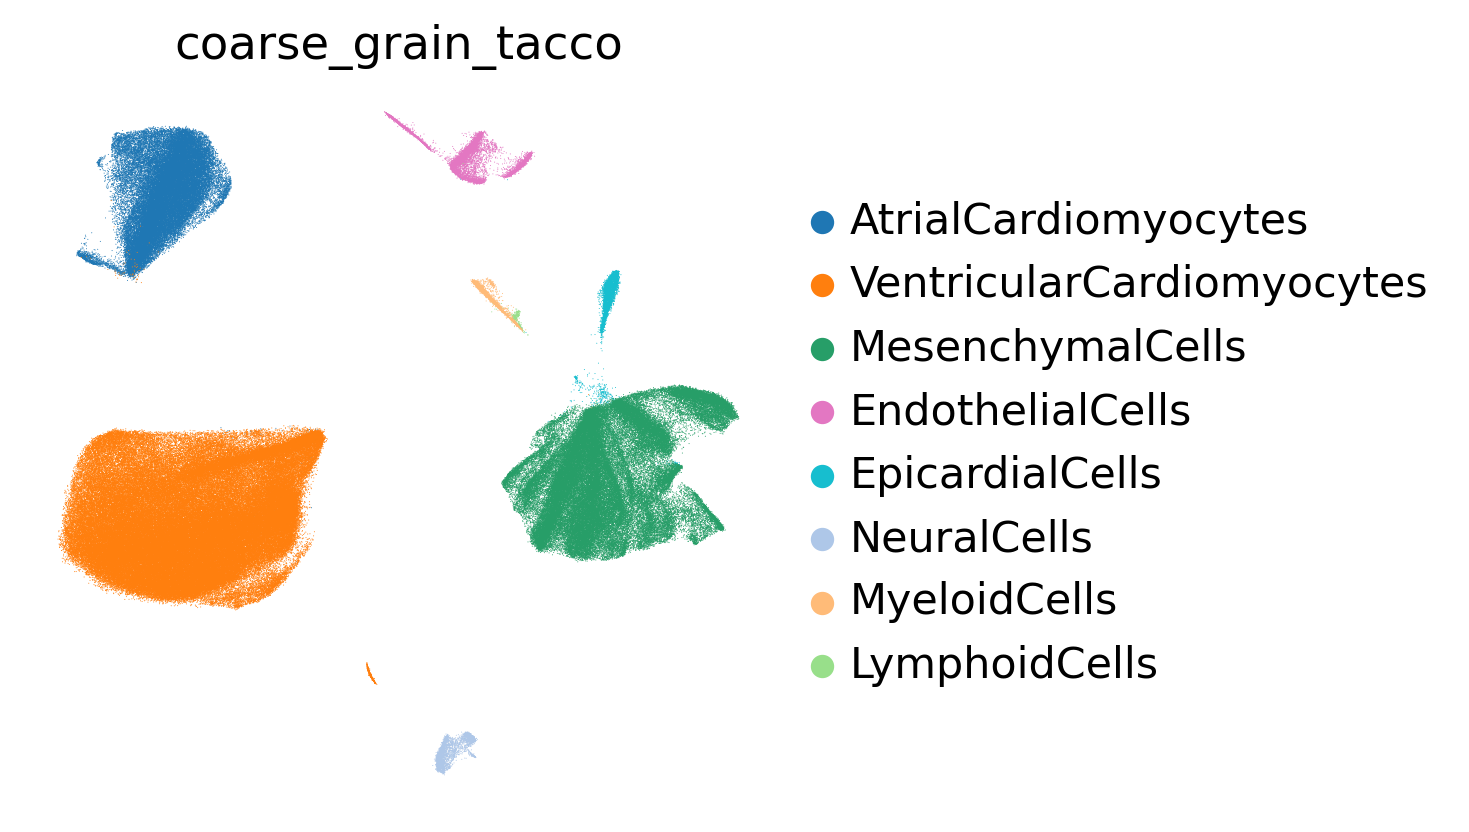

In [32]:
adata.uns['coarse_grain_tacco_colors'] = colors
sc.pl.embedding(adata, basis=f"X_umap_{key_added}",
               color='coarse_grain_tacco',
                frameon=False,
               show=False)
plt.savefig(f'{figdir}/Xenium5K_post-TACCO_UMAP_coarse_grain_tacco.pdf', bbox_inches="tight",dpi=300)